# DESCOMPOSICIÓN Y ANÁLISIS DE LAS SERIES DE LA CARTERA

¡¡¡IMPORTANTE!!! Ejecutar primero el script _01_Ingesta_Limpieza.py

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics import tsaplots
import statsmodels.graphics.tsaplots as sgt
from arch import arch_model

## 1<sup>er</sup> activo: APPLE (AAPL)

In [58]:
rentabilidades = pd.read_csv('Datos/Limpios/Cartera_Rent.csv', index_col='trading_day')
aapl_rent = rentabilidades['AAPL']*100
aapl_rent

trading_day
2020-06-03    0.450712
2020-06-04    0.577018
2020-06-05   -0.164165
2020-06-06    1.972370
2020-06-07    0.000000
                ...   
2021-06-27   -0.224871
2021-06-28    0.019184
2021-06-29    1.237948
2021-06-30    1.147257
2021-07-01    0.000000
Name: AAPL, Length: 394, dtype: float64

In [59]:
cartera = pd.read_csv('Datos/Limpios/Cartera_Close.csv', index_col='trading_day')
aapl = cartera['AAPL']
aapl

trading_day
2020-06-03     80.703070
2020-06-04     81.168741
2020-06-05     81.035490
2020-06-06     82.633810
2020-06-07     82.633810
                 ...    
2021-06-27    133.110000
2021-06-28    133.135535
2021-06-29    134.783684
2021-06-30    136.330000
2021-07-01    136.330000
Name: AAPL, Length: 394, dtype: float64

<Axes: xlabel='trading_day'>

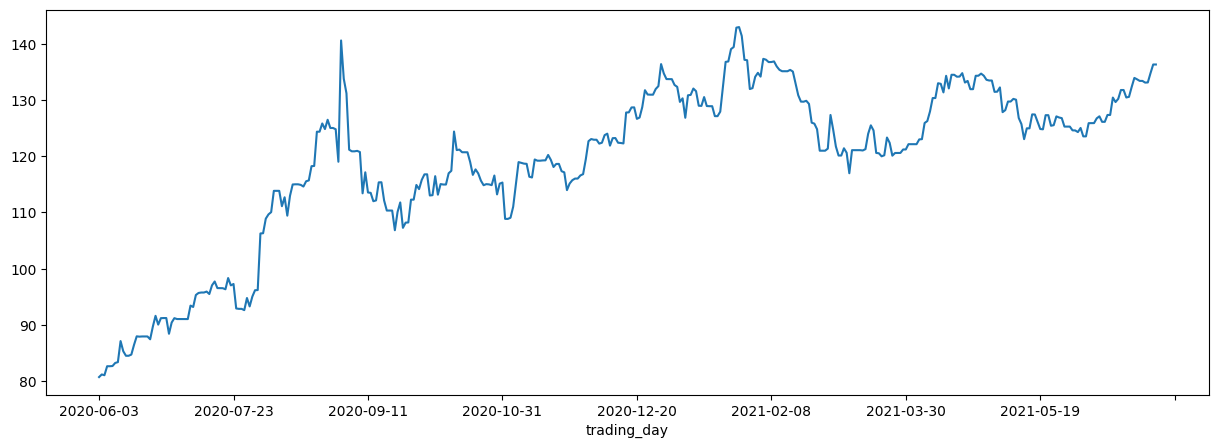

In [60]:
aapl.plot(figsize=(15,5))

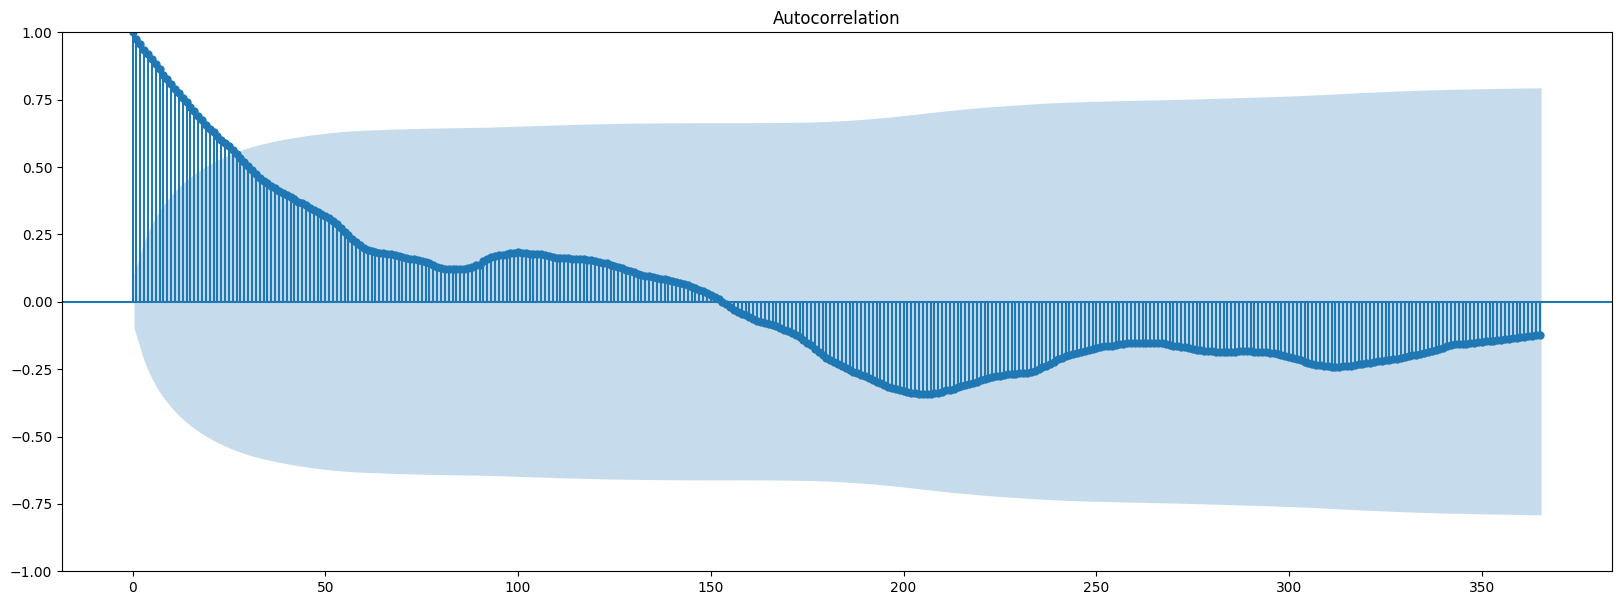

In [61]:
tsaplots.plot_acf(aapl, lags=365)
plt.show()

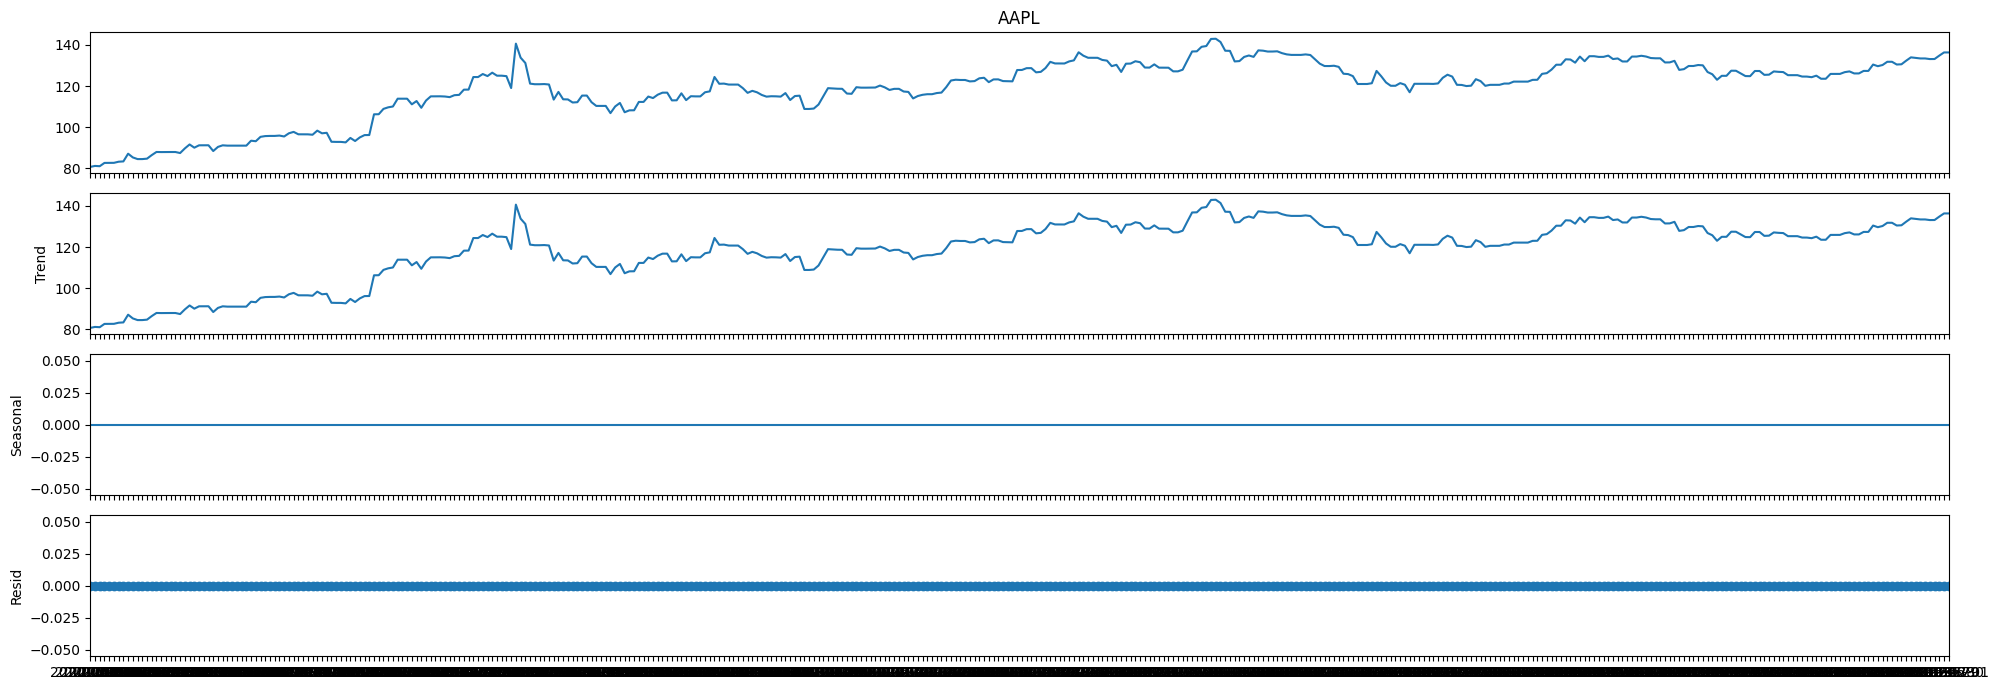

In [62]:
decomposicion = seasonal_decompose(aapl, model='aditive', period=1)
decomposicion.plot()
plt.show()

NO TIENE SENTIDO USAR SEASONAL DECOMPOSE

<Axes: xlabel='trading_day'>

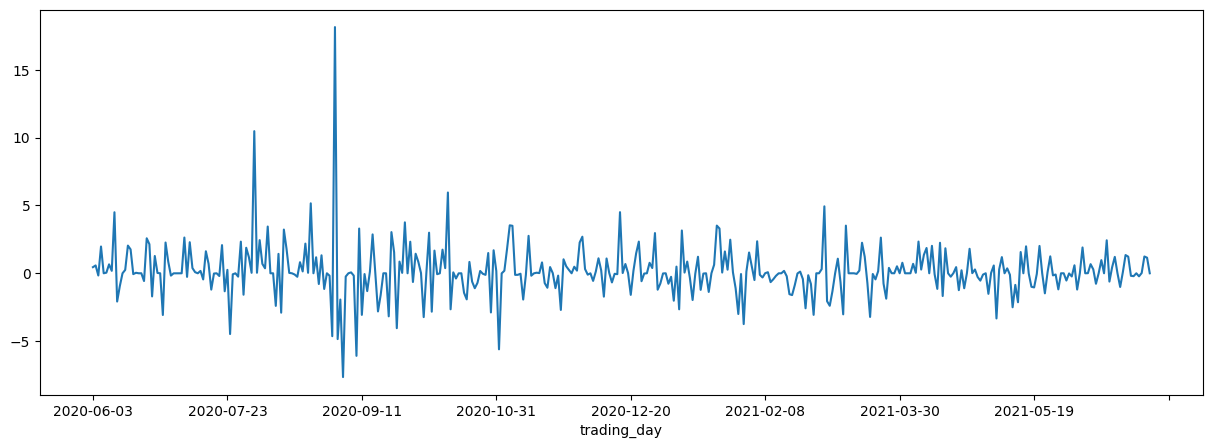

In [63]:
aapl_rent.plot(figsize=(15,5))

In [64]:
#PASAMOS TESTS DE ESTACIONARIA EN MEDIA

result = adfuller(aapl_rent)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
print(f'Result: The series is {"not " if result[1] > 0.05 else ""}stationary')

ADF Statistic: -23.27916644848975
p-value: 0.0
Critial Values:
   1%, -3.447099431978147
Critial Values:
   5%, -2.8689225261604263
Critial Values:
   10%, -2.57070269105012
Result: The series is stationary


In [65]:
statistic, p_value, n_lags, critical_values = kpss(aapl_rent)
print(f'KPSS Statistic: {statistic}')
print(f'p-value: {p_value}')
print('Critial Values:')
for key, value in critical_values.items():
    print(f'   {key} : {value}')
print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

KPSS Statistic: 0.25468103481107085
p-value: 0.1
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12256\3367826852.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(aapl_rent)


In [66]:
# PASAMOS TEST DE HETEROCEDASTICIDAD

lm_test = het_arch(aapl_rent)

print("Resultados del ARCH test:")
print(f"P-valor F: {lm_test[3]:.4f}")

Resultados del ARCH test:
P-valor F: 0.1034


ES MAYOR QUE 0.05, NO PRESENTA HETEROCEDASTICIDAD, ES ESTRICTAMENTE ESTACIONARIA

## 2<sup>o</sup> activo: MICROSOFT (MSFT)

In [67]:
msft_rent = pd.DataFrame(rentabilidades['MSFT']*100)
msft_rent

,MSFT
trading_day,
2020-06-03,0.000000
2020-06-04,1.381091
2020-06-05,-1.311787
2020-06-06,-0.004631
2020-06-07,0.000000
...,...
2021-06-27,-0.614588
2021-06-28,0.039513
2021-06-29,1.353238


In [68]:
msft = pd.DataFrame(cartera['MSFT'])
msft

,MSFT
trading_day,
2020-06-03,182.834884
2020-06-04,185.360000
2020-06-05,182.928472
2020-06-06,182.920000
2020-06-07,182.920000
...,...
2021-06-27,265.020000
2021-06-28,265.124717
2021-06-29,268.712484


<Axes: xlabel='trading_day'>

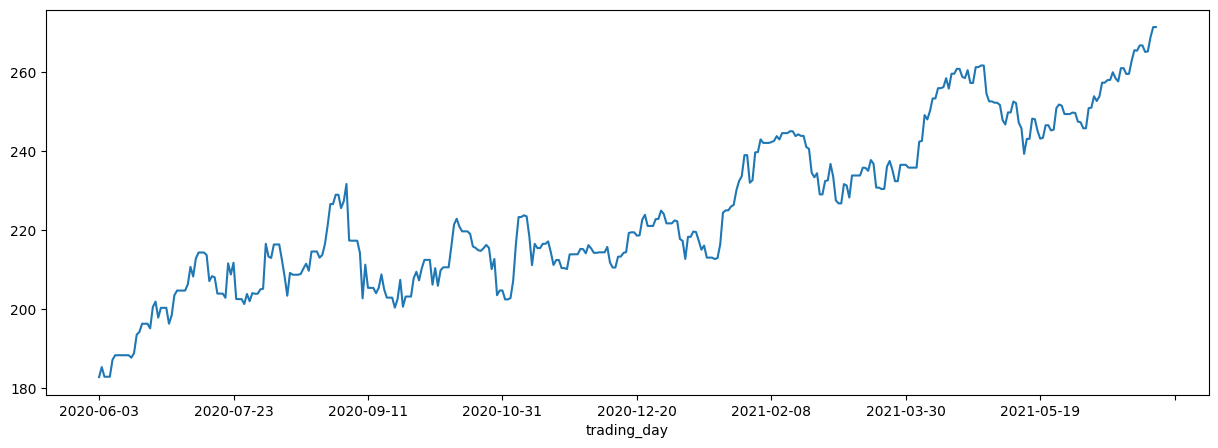

In [69]:
msft['MSFT'].plot(figsize=(15,5))

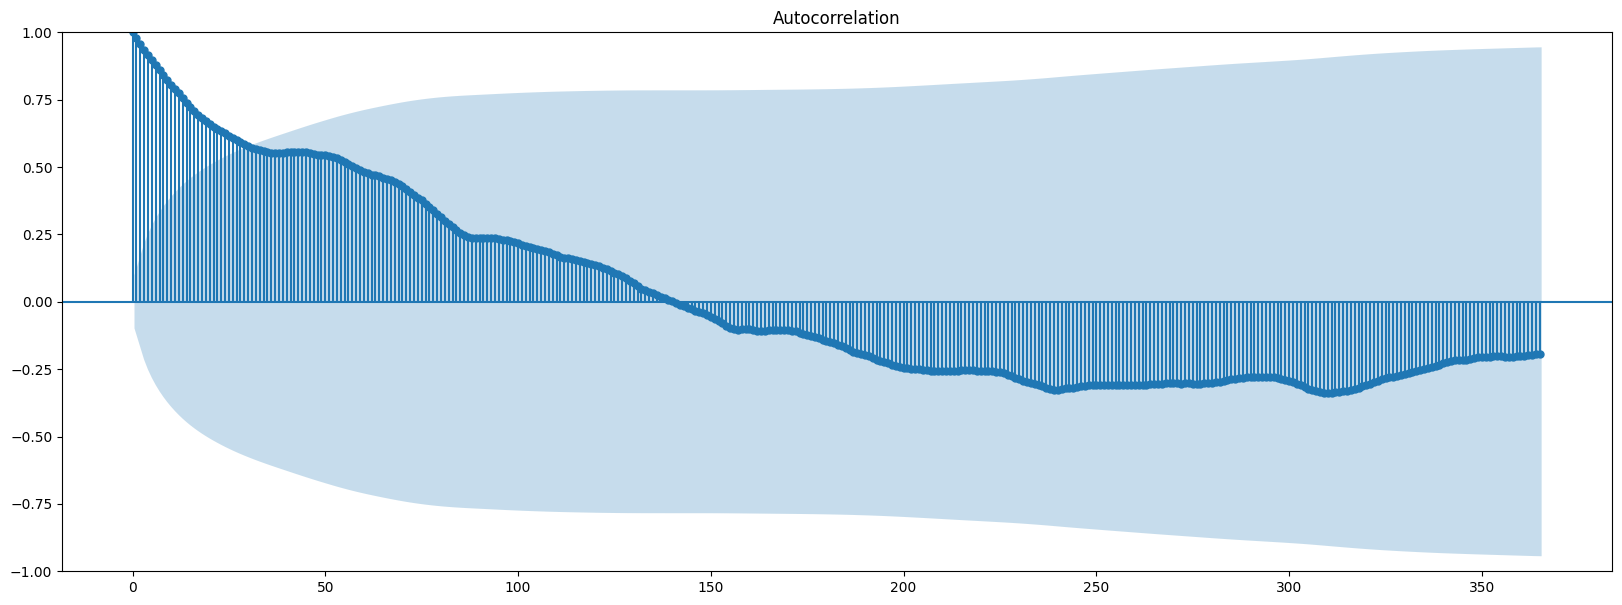

In [70]:
tsaplots.plot_acf(msft['MSFT'], lags=365)
plt.show()

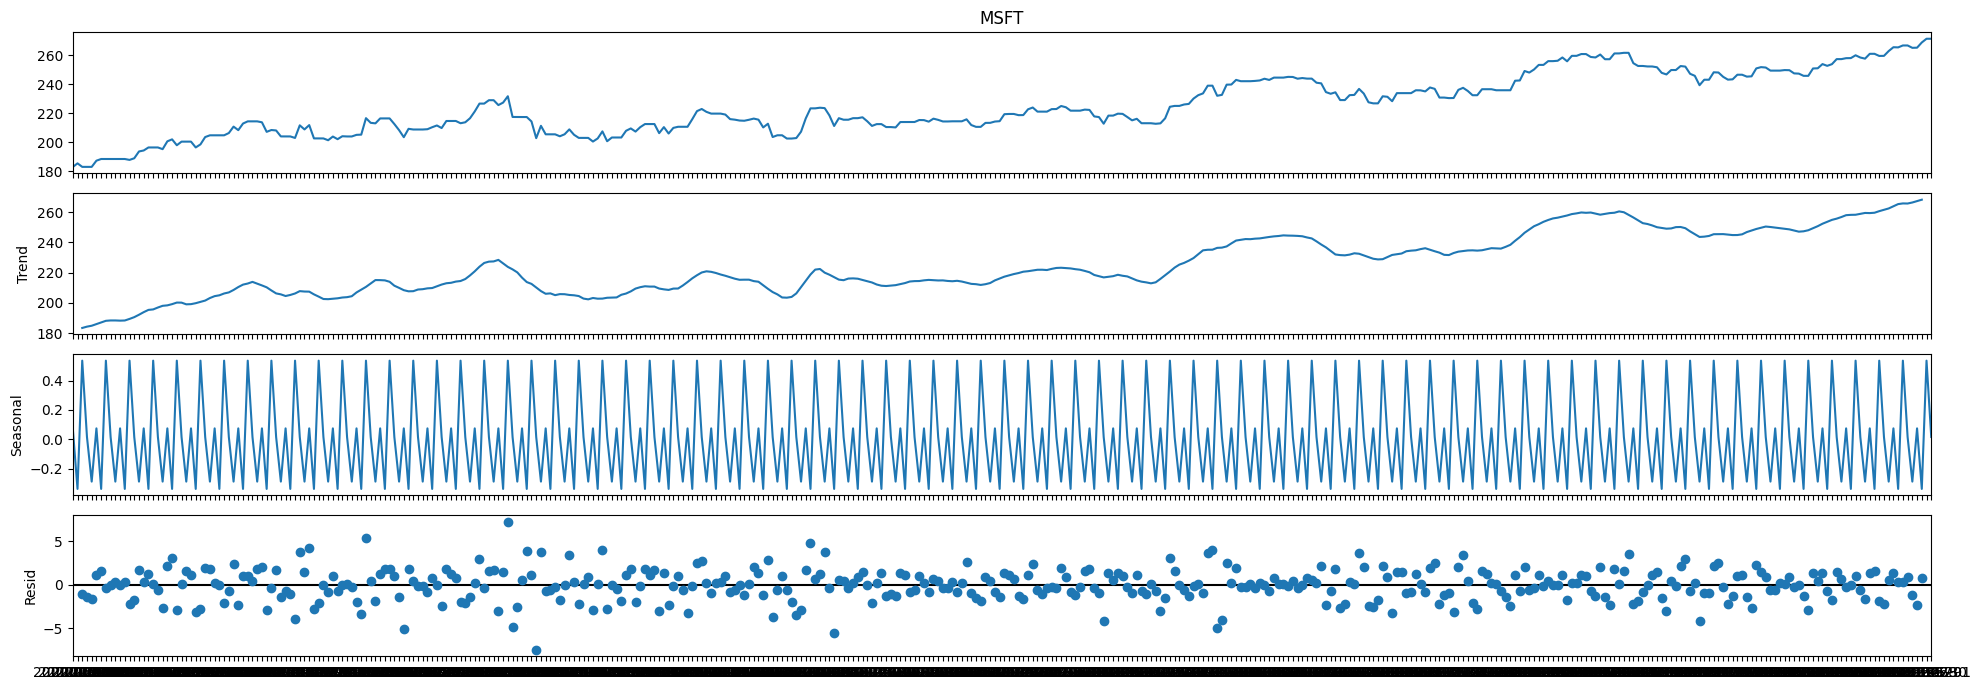

In [71]:
decomposicion = seasonal_decompose(msft['MSFT'], model='aditive', period=5)
decomposicion.plot()
plt.show()

<Axes: xlabel='trading_day'>

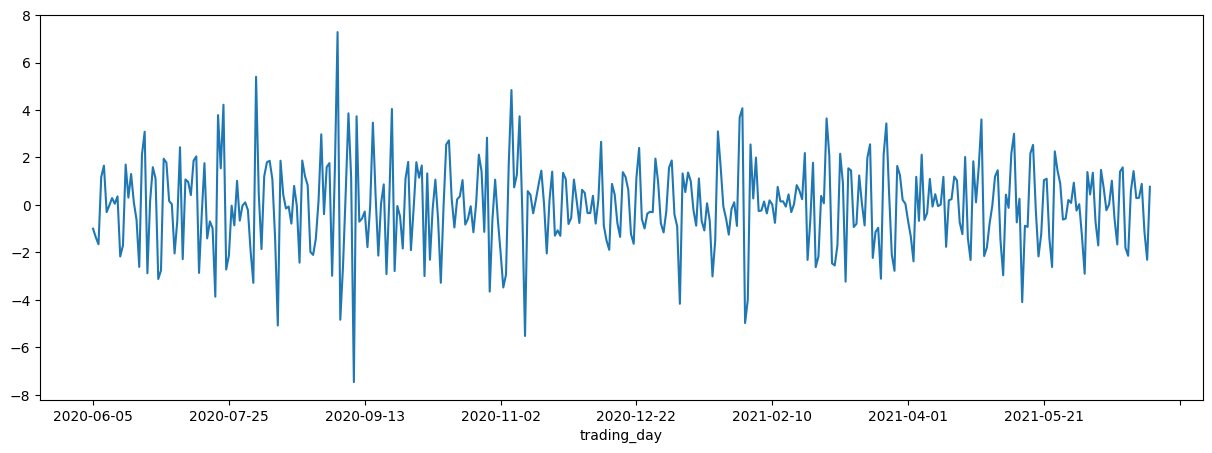

In [72]:
decomposicion.resid.dropna().plot(figsize=(15,5))

NO TIENE SENTIDO USAR SEASONAL DECOMPOSE

<Axes: xlabel='trading_day'>

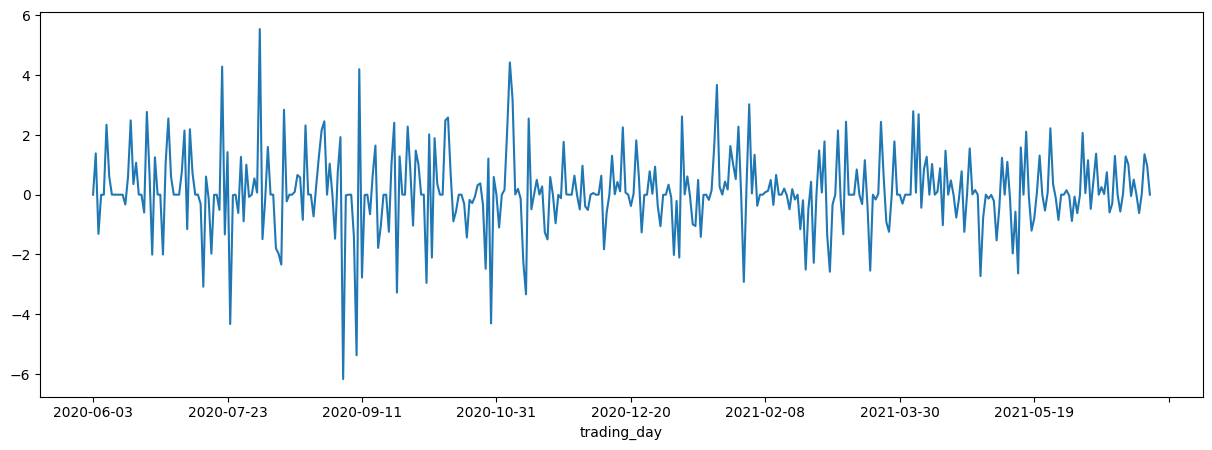

In [73]:
msft_rent['MSFT'].plot(figsize=(15,5))

In [74]:
#PASAMOS TESTS DE ESTACIONARIA EN MEDIA

result = adfuller(msft_rent['MSFT'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
print(f'Result: The series is {"not " if result[1] > 0.05 else ""}stationary')

ADF Statistic: -21.46588569801467
p-value: 0.0
Critial Values:
   1%, -3.447099431978147
Critial Values:
   5%, -2.8689225261604263
Critial Values:
   10%, -2.57070269105012
Result: The series is stationary


In [75]:
statistic, p_value, n_lags, critical_values = kpss(msft_rent['MSFT'])
print(f'KPSS Statistic: {statistic}')
print(f'p-value: {p_value}')
print('Critial Values:')
for key, value in critical_values.items():
    print(f'   {key} : {value}')
print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

KPSS Statistic: 0.03747177415121866
p-value: 0.1
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12256\1755923010.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(msft_rent['MSFT'])


In [76]:
# PASAMOS TEST DE HETEROCEDASTICIDAD

lm_test = het_arch(msft_rent['MSFT'])

print("Resultados del ARCH test:")
print(f"P-valor F: {lm_test[3]:.4f}")

Resultados del ARCH test:
P-valor F: 0.0002


NO ES ESTRICTAMENTE ESTACIONARIA, VAMOS A MODELIZAR LA VOLATILIDAD

In [85]:
msft_rent['vol'] = msft_rent['MSFT'].mul(msft_rent['MSFT'])

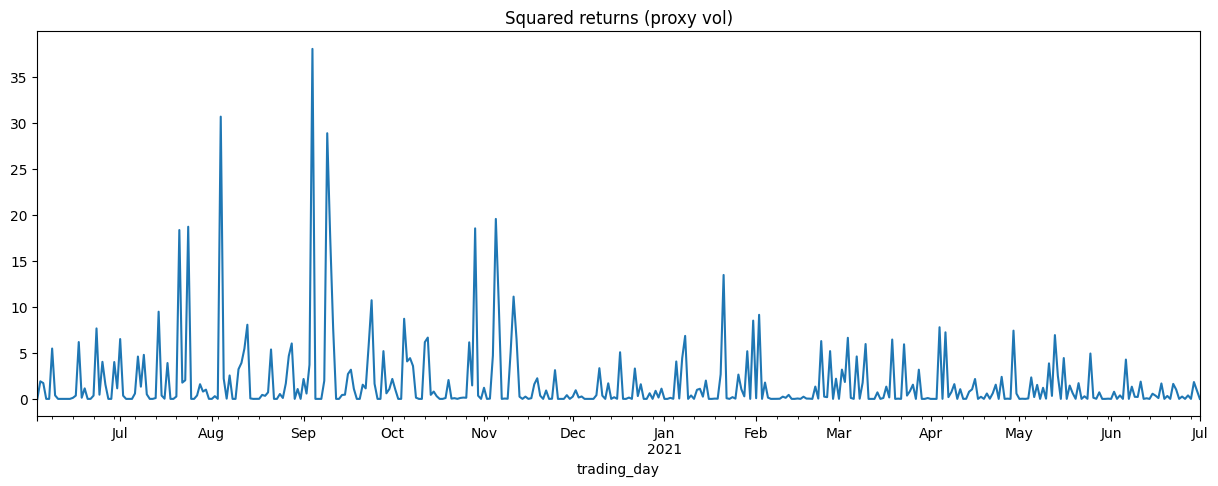

In [86]:
plt.figure(figsize=(15,5)); msft_rent['vol'].plot(title='Squared returns (proxy vol)'); plt.show()

In [88]:
msft_rent.index = pd.to_datetime(msft_rent.index)

In [89]:
train_df = msft_rent.loc[:"2021-05-14"]
test_df = msft_rent.loc["2021-05-15":]

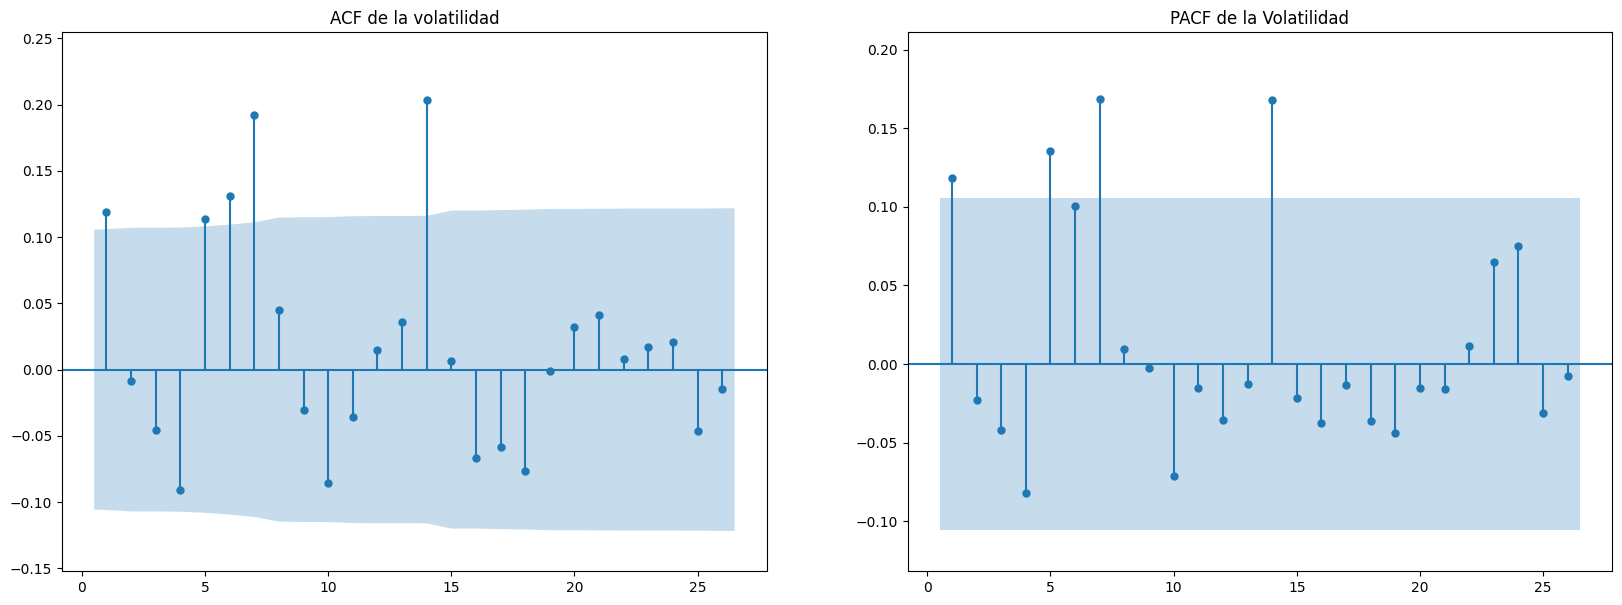

In [90]:
plt.rcParams["figure.figsize"] = (20, 7)

fig, ax = plt.subplots(1,2)

sgt.plot_acf(train_df.vol[1:],ax=ax[0],zero = False, auto_ylims=True, title="ACF de la volatilidad")
sgt.plot_pacf(train_df.vol[1:],ax=ax[1], zero = False,auto_ylims=True,title="PACF de la Volatilidad");

PROBAMOS ARCH(1) Y GARCH(1,1)

ARCH(1)

In [91]:
modelo_arch_1 = arch_model(msft_rent.MSFT[1:], vol="ARCH", p=1, mean="AR")
resultados_arch_1 = modelo_arch_1.fit(last_obs = test_df.index[0])
resultados_arch_1.summary()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 1020.3926414879878
Iteration:      2,   Func. Count:     11,   Neg. LLF: 635.2769884777563
Iteration:      3,   Func. Count:     17,   Neg. LLF: 603.2090276377061
Iteration:      4,   Func. Count:     22,   Neg. LLF: 597.3114339750248
Iteration:      5,   Func. Count:     27,   Neg. LLF: 597.2688855957507
Iteration:      6,   Func. Count:     31,   Neg. LLF: 597.2688839921082
Iteration:      7,   Func. Count:     34,   Neg. LLF: 597.2688839921093
Optimization terminated successfully    (Exit mode 0)
            Current function value: 597.2688839921082
            Iterations: 7
            Function evaluations: 34
            Gradient evaluations: 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - ARCH Model Results                            
==============================================================================
Dep. Variable:                   MSFT   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -597.269
Distribution:                  Normal   AIC:                           1200.54
Method:            Maximum Likelihood   BIC:                           1212.07
                                        No. Observations:                  345
Date:                Tue, Oct 21 2025   Df Residuals:                      344
Time:                        12:01:12   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.0730  7.472e-02      0.977      0.328 [-7.343e-02,  0.219]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          1.5967      0.238      6.716  1.873e-11    [  1.131,  2.063]
alpha[1]       0.1867      0.142      1.315      0.189 [-9.166e-02,  0.465]
===========================================================================

Covariance estimator: robust
"""

GARCH(1,1)

In [92]:
modelo_garch = arch_model(msft_rent.vol[1:], vol="GARCH", p=1, q=1)
resultados_garch = modelo_garch.fit(last_obs = test_df.index[0])
resultados_garch.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1714.9505965382548
Iteration:      2,   Func. Count:     15,   Neg. LLF: 924069.9577214613
Iteration:      3,   Func. Count:     22,   Neg. LLF: 1309.425469381106
Iteration:      4,   Func. Count:     28,   Neg. LLF: 968.2787058332883
Iteration:      5,   Func. Count:     34,   Neg. LLF: 995.0547582651751
Iteration:      6,   Func. Count:     40,   Neg. LLF: 961.6775266323016
Iteration:      7,   Func. Count:     45,   Neg. LLF: 961.5808437432546
Iteration:      8,   Func. Count:     51,   Neg. LLF: 1026.9697305676755
Iteration:      9,   Func. Count:     58,   Neg. LLF: 961.3186820715986
Iteration:     10,   Func. Count:     64,   Neg. LLF: 960.8074067553748
Iteration:     11,   Func. Count:     69,   Neg. LLF: 960.8072164627681
Iteration:     12,   Func. Count:     74,   Neg. LLF: 960.8071988076281
Iteration:     13,   Func. Count:     78,   Neg. LLF: 960.8071985331392
Optimization terminated successfully    (Exit mode 0)
        

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                    vol   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -960.807
Distribution:                  Normal   AIC:                           1929.61
Method:            Maximum Likelihood   BIC:                           1944.99
                                        No. Observations:                  345
Date:                Tue, Oct 21 2025   Df Residuals:                      344
Time:                        12:05:21   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1.6260      0.179      9.083  1.060e-19 [  1.275,  1.977]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1445      0.226      0.639      0.523    [ -0.298,  0.587]
alpha[1]       0.0471  2.985e-02      1.579      0.114 [-1.138e-02,  0.106]
beta[1]        0.9529  1.574e-02     60.525      0.000    [  0.922,  0.984]
===========================================================================

Covariance estimator: robust
"""

In [93]:
arch1_resid = resultados_arch_1.std_resid
arch11_resid = resultados_garch.std_resid

In [94]:
lm_test = het_arch(arch1_resid.dropna())

print("Resultados del ARCH test:")
print(f"Estadístico LM: {lm_test[0]:.4f}")
print(f"P-valor LM: {lm_test[1]:.4f}")
print(f"Estadístico F: {lm_test[2]:.4f}")
print(f"P-valor F: {lm_test[3]:.4f}")

Resultados del ARCH test:
Estadístico LM: 14.8766
P-valor LM: 0.1366
Estadístico F: 1.5057
P-valor F: 0.1358


In [95]:
lm_test = het_arch(arch11_resid.dropna())

print("Resultados del ARCH test:")
print(f"Estadístico LM: {lm_test[0]:.4f}")
print(f"P-valor LM: {lm_test[1]:.4f}")
print(f"Estadístico F: {lm_test[2]:.4f}")
print(f"P-valor F: {lm_test[3]:.4f}")

Resultados del ARCH test:
Estadístico LM: 3.0469
P-valor LM: 0.9803
Estadístico F: 0.2974
P-valor F: 0.9815
